# ABC2Vec — Notebook 01: Data Pipeline

This notebook sets up the complete data pipeline for the ABC2Vec project:

1. **Install all dependencies** for the entire project
2. **Download datasets** — IrishMAN (214K tunes)
3. **Explore & visualize** dataset statistics
4. **Normalize & clean** ABC notation
5. **Deduplicate** the corpus
6. **Extract metadata** (tune type, key/mode, time signature, structure)
7. **Create train/val/test splits** 
8. **Save processed data** to disk for downstream notebooks

> **Note:** `sander-wood/abc_cc` on HuggingFace is identical to IrishMAN (same 214K tunes,
> same `abc notation` column) — only the control code annotations differ. We use IrishMAN directly.

## 1.1 Install Dependencies

Install all packages needed across all notebooks in the ABC2Vec project.

In [1]:
import subprocess, sys

# packages = [
#     "torch", "torchvision", "torchaudio",
#     "transformers", "datasets", "tokenizers",
#     "music21",
#     "faiss-cpu",
#     "umap-learn",
#     "scikit-learn",
#     "matplotlib", "seaborn", "plotly",
#     "pandas", "numpy",
#     "tqdm",
#     "requests",
#     "Levenshtein",  # for edit-distance similarity
#     "scipy",
#     "wandb",  # optional: experiment tracking
#     "accelerate",
#     "einops",
#     "rich",
#     "pyarrow"
# ]

# for pkg in packages:
#     subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", pkg])

# print("All dependencies installed.")

In [2]:
import os, re, json, hashlib, collections, warnings, textwrap
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.auto import tqdm
from datasets import load_dataset, Dataset, DatasetDict

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', font_scale=1.1)

# Project root
PROJECT_DIR = Path('/Volumes/LLModels/ABC2VEC')
DATA_DIR = PROJECT_DIR / 'data'
RAW_DIR = DATA_DIR / 'raw'
PROCESSED_DIR = DATA_DIR / 'processed'
BENCHMARK_DIR = DATA_DIR / 'benchmark'

for d in [DATA_DIR, RAW_DIR, PROCESSED_DIR, BENCHMARK_DIR]:
    d.mkdir(parents=True, exist_ok=True)

print(f"Project directory: {PROJECT_DIR}")
print(f"Data directory:    {DATA_DIR}")

Project directory: /Volumes/LLModels/ABC2VEC
Data directory:    /Volumes/LLModels/ABC2VEC/data


## 1.2 Download Datasets

### Primary pre-training corpus: IrishMAN (214K tunes)
### `abc_cc` is downloaded for reference but contains identical tunes — IrishMAN is used as the sole source.

In [3]:
# ─── Download IrishMAN from HuggingFace ───
print("Downloading IrishMAN (216K Irish folk tunes)...")
irishman_ds = load_dataset("sander-wood/irishman")
print(f"IrishMAN loaded: {irishman_ds}")
print(f"  Train: {len(irishman_ds['train']):,} tunes")
print(f"  Valid: {len(irishman_ds['validation']):,} tunes")
print(f"  Columns: {irishman_ds['train'].column_names}")
print(f"\nFirst tune preview:")
print(irishman_ds['train'][0]['abc'][:500] if 'abc' in irishman_ds['train'].column_names else irishman_ds['train'][0])

IrishMAN loaded: DatasetDict({
    train: Dataset({
        features: ['abc notation', 'control code'],
        num_rows: 214122
    })
    validation: Dataset({
        features: ['abc notation', 'control code'],
        num_rows: 2162
    })
})
  Train: 214,122 tunes
  Valid: 2,162 tunes
  Columns: ['abc notation', 'control code']

First tune preview:
{'abc notation': 'X:1\nL:1/8\nM:4/4\nK:Emin\n|: E2 EF E2 EF | DEFG AFDF | E2 EF E2 B2 |1 efe^d e2 e2 :|2 efe^d e3 B |: e2 ef g2 fe | \n defg afdf |1 e2 ef g2 fe | efe^d e3 B :|2 g2 bg f2 af | efe^d e2 e2 ||', 'control code': 'S:2\nB:5\nE:5\nB:6\n'}


In [4]:
# ─── Download abc_cc from HuggingFace ───
print("Downloading abc_cc (285K folk tunes with control codes)...")
abc_cc_ds = load_dataset("sander-wood/abc_cc")
print(f"abc_cc loaded: {abc_cc_ds}")
for split in abc_cc_ds:
    print(f"  {split}: {len(abc_cc_ds[split]):,} tunes")
print(f"  Columns: {abc_cc_ds[list(abc_cc_ds.keys())[0]].column_names}")
print(f"\nFirst tune preview:")
first_key = list(abc_cc_ds.keys())[0]
sample = abc_cc_ds[first_key][0]
print(str(sample)[:500])

abc_cc loaded: DatasetDict({
    train: Dataset({
        features: ['control code', 'abc notation'],
        num_rows: 214122
    })
    validation: Dataset({
        features: ['control code', 'abc notation'],
        num_rows: 2162
    })
})
  train: 214,122 tunes
  validation: 2,162 tunes
  Columns: ['control code', 'abc notation']

First tune preview:
{'control code': 'S:2\nB:5\nE:5\nB:6\n', 'abc notation': 'X:1\nL:1/8\nM:4/4\nK:Emin\n|: E2 EF E2 EF | DEFG AFDF | E2 EF E2 B2 |1 efe^d e2 e2 :|2 efe^d e3 B |: e2 ef g2 fe | \n defg afdf |1 e2 ef g2 fe | efe^d e3 B :|2 g2 bg f2 af | efe^d e2 e2 ||'}


## 1.3 Explore & Understand the Data

Let's understand the structure and statistics of our primary dataset (IrishMAN).

In [5]:
# ─── Determine the text column name ───
# IrishMAN stores ABC tunes as text — find the column
train_ds = irishman_ds['train']
sample = train_ds[0]
print("Column names:", train_ds.column_names)
print("\nSample entry (first 5 fields):")
for k, v in list(sample.items())[:5]:
    print(f"  {k}: {str(v)[:200]}")

# Identify the ABC text column
text_col = None
for col in train_ds.column_names:
    val = str(sample[col])
    if 'X:' in val or '|' in val or 'M:' in val or 'K:' in val:
        text_col = col
        break
if text_col is None:
    # Fallback: use the first string column
    text_col = train_ds.column_names[0]

print(f"\nUsing column '{text_col}' as ABC text column")
print(f"\nFull first tune:\n{train_ds[0][text_col]}")

Column names: ['abc notation', 'control code']

Sample entry (first 5 fields):
  abc notation: X:1
L:1/8
M:4/4
K:Emin
|: E2 EF E2 EF | DEFG AFDF | E2 EF E2 B2 |1 efe^d e2 e2 :|2 efe^d e3 B |: e2 ef g2 fe | 
 defg afdf |1 e2 ef g2 fe | efe^d e3 B :|2 g2 bg f2 af | efe^d e2 e2 ||
  control code: S:2
B:5
E:5
B:6


Using column 'abc notation' as ABC text column

Full first tune:
X:1
L:1/8
M:4/4
K:Emin
|: E2 EF E2 EF | DEFG AFDF | E2 EF E2 B2 |1 efe^d e2 e2 :|2 efe^d e3 B |: e2 ef g2 fe | 
 defg afdf |1 e2 ef g2 fe | efe^d e3 B :|2 g2 bg f2 af | efe^d e2 e2 ||


In [6]:
# ─── Show a few diverse tunes ───
print("=" * 80)
for idx in [0, 100, 1000, 5000, 50000]:
    if idx < len(train_ds):
        print(f"\n--- Tune #{idx} ---")
        print(train_ds[idx][text_col][:400])
        print("=" * 80)


--- Tune #0 ---
X:1
L:1/8
M:4/4
K:Emin
|: E2 EF E2 EF | DEFG AFDF | E2 EF E2 B2 |1 efe^d e2 e2 :|2 efe^d e3 B |: e2 ef g2 fe | 
 defg afdf |1 e2 ef g2 fe | efe^d e3 B :|2 g2 bg f2 af | efe^d e2 e2 ||

--- Tune #100 ---
X:101
L:1/4
Q:3/4=90
M:6/4
K:C
 d B G d B G | g2 e c3/2 d/e/f/ | d B G d B G |1 d2 B G3 :|2 d2 B G2 |: G | G A G G B2 | 
 A B A c e2 | d B G G A B |1 A2 G G2 :|2 A2 G G3 :|

--- Tune #1000 ---
X:1001
L:1/16
M:2/4
K:G
|: FE | D2G2 G2FG | A2d2- d2>e2 | fgfe dedc | A2F2 GAGF | D2G2- G2FG | A2d2 d2>e2 | fgfe cAFA | 
 G2B2 G2 ::[K:D] cB | A2f2 fedc | B2G2 g2>B2 | A2a2 gfed | f2e2 e2FG | A2d2 fedc | d2G2 B2>G2 | 
 A2a2 gfe2 | d4 d2 :|

--- Tune #5000 ---
X:5001
L:1/8
M:2/4
K:G
 (D |{EF} G)GAB | GBAD |{EF} GGAB | (G2 F) D |{EF} GGAB | cBAG | EDEE | G2 G z | ([EC]>FE)D | 
 [EC]F [GE]2 | (D>ED)C | (B,C) [DB,] z | ([EC]>FE)D | [EC]FGE | DGFA | G2 G z |]

--- Tune #50000 ---
X:50001
L:1/8
M:4/4
K:Edor
 E | G A B c | B A G E | F/G/ A F G | E3 :| E | G A B/c/ d | c B2 B/c/ | d d A3/

In [7]:
# ─── Basic Statistics ───
print("Computing basic statistics over IrishMAN train set...")

# Meter → tune type mapping for Irish/British folk music
METER_TO_TYPE = {
    '4/4':  'reel',
    '2/2':  'reel',
    'C':    'reel',
    '6/8':  'jig',
    '12/8': 'double jig',
    '9/8':  'slip jig',
    '3/8':  'slip jig',
    '2/4':  'polka',
    '3/4':  'waltz',
    '6/4':  'march',
    '4/8':  'hornpipe',
}

# Ordered longest-first so 'slip jig' matches before 'jig', 'double jig' before 'jig'
TUNE_TYPE_KEYWORDS = [
    'double jig', 'slip jig', 'single jig', 'jig',
    'hornpipe', 'reel', 'polka', 'waltz', 'march',
    'air', 'strathspey', 'slide', 'mazurka', 'barndance', 'schottische',
]

def infer_tune_type(abc_text: str) -> str:
    """
    Infer tune type: R: field > T: keywords > meter-based fallback.
    """
    meter = ''
    for line in abc_text.split('\n'):
        line = line.strip()
        if line.startswith('R:'):
            return line[2:].strip().lower()
        if line.startswith('M:'):
            meter = line[2:].strip()

    # Scan T: title for type keywords
    for line in abc_text.split('\n'):
        if line.strip().startswith('T:'):
            line_lower = line.lower()
            for kw in TUNE_TYPE_KEYWORDS:
                if kw in line_lower:
                    return kw

    # Fallback: infer from meter
    return METER_TO_TYPE.get(meter, '')

lengths = []
bar_counts = []
keys = []
meters = []
tune_types = []

for i in tqdm(range(len(train_ds)), desc="Scanning tunes"):
    abc = train_ds[i][text_col]
    lengths.append(len(abc))
    bar_counts.append(abc.count('|'))

    for line in abc.split('\n'):
        line = line.strip()
        if line.startswith('K:'):
            keys.append(line[2:].strip())
        elif line.startswith('M:'):
            meters.append(line[2:].strip())

    t = infer_tune_type(abc)
    if t:
        tune_types.append(t)

print(f"\n{'='*50}")
print(f"Total tunes: {len(train_ds):,}")
print(f"Char lengths  — mean: {np.mean(lengths):.0f}, median: {np.median(lengths):.0f}, "
      f"min: {np.min(lengths)}, max: {np.max(lengths)}")
print(f"Bar counts    — mean: {np.mean(bar_counts):.1f}, median: {np.median(bar_counts):.0f}")
print(f"Unique keys:  {len(set(keys))}")
print(f"Unique meters: {len(set(meters))}")
print(f"Tunes with type info: {len(tune_types):,} / {len(train_ds):,}")
print(f"\nTop 10 keys:")
for k, c in collections.Counter(keys).most_common(10):
    print(f"  {k}: {c:,}")
print(f"\nTop 10 meters:")
for m, c in collections.Counter(meters).most_common(10):
    print(f"  {m}: {c:,}")
print(f"\nTop 15 tune types:")
for t, c in collections.Counter(tune_types).most_common(15):
    print(f"  {t}: {c:,}")

Computing basic statistics over IrishMAN train set...


Scanning tunes:   0%|          | 0/214122 [00:00<?, ?it/s]


Total tunes: 214,122
Char lengths  — mean: 290, median: 257, min: 22, max: 2968
Bar counts    — mean: 20.0, median: 18
Unique keys:  62
Unique meters: 80
Tunes with type info: 210,254 / 214,122

Top 10 keys:
  G: 59,848
  D: 49,458
  C: 21,516
  A: 15,614
  F: 12,326
  Emin: 6,699
  Amin: 6,156
  Bb: 6,086
  Ador: 4,916
  Dmin: 4,008

Top 10 meters:
  4/4: 70,726
  6/8: 46,046
  2/4: 30,972
  3/4: 25,790
  2/2: 25,328
  9/8: 4,675
  3/8: 2,513
  6/4: 2,352
  12/8: 1,809
  3/2: 1,767

Top 15 tune types:
  reel: 96,054
  jig: 46,046
  polka: 30,972
  waltz: 25,790
  slip jig: 7,188
  march: 2,352
  double jig: 1,809
  hornpipe: 43


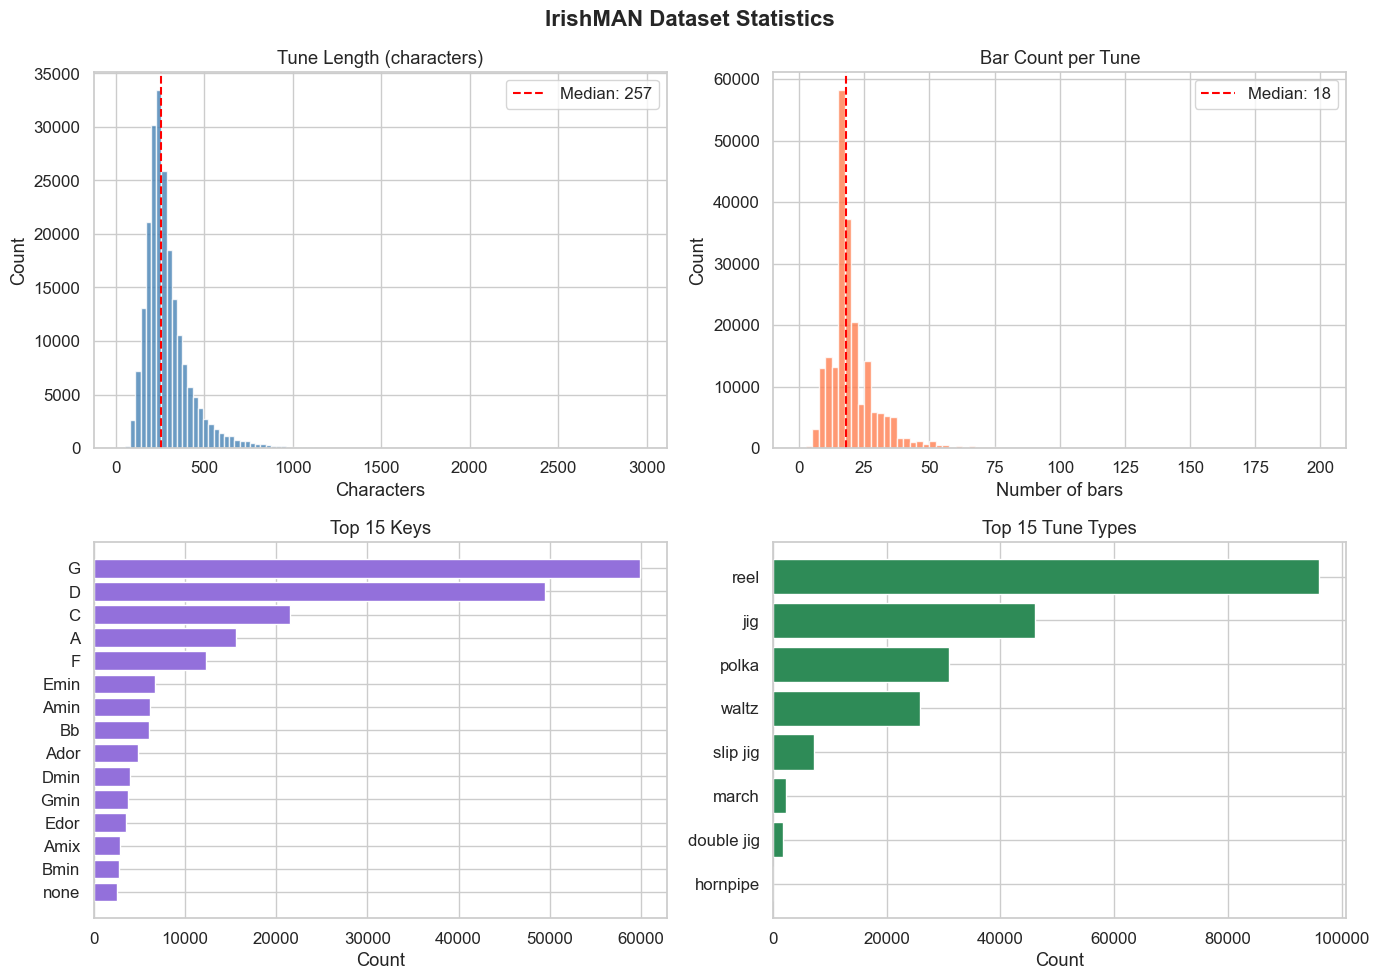

Saved to figures/dataset_statistics.png


In [8]:
# ─── Visualization: Distribution plots ───
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Char length distribution
axes[0, 0].hist(lengths, bins=100, color='steelblue', edgecolor='white', alpha=0.8)
axes[0, 0].set_title('Tune Length (characters)')
axes[0, 0].set_xlabel('Characters')
axes[0, 0].set_ylabel('Count')
axes[0, 0].axvline(np.median(lengths), color='red', linestyle='--', label=f'Median: {np.median(lengths):.0f}')
axes[0, 0].legend()

# Bar count distribution
axes[0, 1].hist(bar_counts, bins=80, color='coral', edgecolor='white', alpha=0.8)
axes[0, 1].set_title('Bar Count per Tune')
axes[0, 1].set_xlabel('Number of bars')
axes[0, 1].set_ylabel('Count')
axes[0, 1].axvline(np.median(bar_counts), color='red', linestyle='--', label=f'Median: {np.median(bar_counts):.0f}')
axes[0, 1].legend()

# Key distribution (top 15)
key_counts = collections.Counter(keys).most_common(15)
axes[1, 0].barh([k for k, _ in key_counts], [c for _, c in key_counts], color='mediumpurple')
axes[1, 0].set_title('Top 15 Keys')
axes[1, 0].set_xlabel('Count')
axes[1, 0].invert_yaxis()

# Tune type distribution (top 15)
type_counts = collections.Counter(tune_types).most_common(15)
axes[1, 1].barh([t for t, _ in type_counts], [c for _, c in type_counts], color='seagreen')
axes[1, 1].set_title('Top 15 Tune Types')
axes[1, 1].set_xlabel('Count')
axes[1, 1].invert_yaxis()

plt.suptitle('IrishMAN Dataset Statistics', fontsize=16, fontweight='bold')
plt.tight_layout()
Path(PROJECT_DIR / 'figures').mkdir(parents=True, exist_ok=True)
plt.savefig(PROJECT_DIR / 'figures' / 'dataset_statistics.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved to figures/dataset_statistics.png")

## 1.4 ABC Notation Normalization & Cleaning

Standardize the ABC notation to ensure consistency:
- Strip control codes (S:, B:, E: prefixes from abc_cc)
- Normalize whitespace and line endings
- Validate ABC structure (must have K: field, at least one bar)
- Remove empty/corrupt tunes
- Extract and separate header info from body

In [9]:
def normalize_abc(abc_text: str) -> dict | None:
    """
    Normalize an ABC tune and extract metadata.
    Returns dict with 'abc_clean', 'abc_body', 'header', 'key', 'meter', 
    'tune_type', 'num_bars', 'sections' or None if invalid.
    """
    if not abc_text or not isinstance(abc_text, str):
        return None
    
    lines = abc_text.strip().split('\n')
    
    # Strip TunesFormer control codes (S:, B:, E: at the very beginning)
    cleaned_lines = []
    for line in lines:
        stripped = line.strip()
        # Skip control code lines (S:number, B:number, E:number)
        if re.match(r'^[SBE]:\d+$', stripped):
            continue
        cleaned_lines.append(stripped)
    
    # Separate header and body
    header_lines = []
    body_lines = []
    in_body = False
    
    header_info = {
        'key': '', 'meter': '', 'tune_type': '',
        'unit_length': '', 'title': ''
    }
    
    for line in cleaned_lines:
        if not line:
            continue
        # ABC header fields start with a letter followed by colon
        if not in_body and re.match(r'^[A-Za-z]:', line):
            header_lines.append(line)
            field = line[0].upper()
            value = line[2:].strip()
            if field == 'K':
                header_info['key'] = value
                in_body = True  # K: is always the last header field in ABC
            elif field == 'M':
                header_info['meter'] = value
            elif field == 'R':
                header_info['tune_type'] = value.lower()
            elif field == 'L':
                header_info['unit_length'] = value
            elif field == 'T':
                if not header_info['title']:  # keep first T: field
                    header_info['title'] = value
        else:
            in_body = True
            body_lines.append(line)

    # Fallback type inference when no R: field is present.
    # Priority: T: title keywords > meter.
    # Note: hornpipe titles commonly contain "hornpipe" explicitly, which
    # meter-only inference cannot distinguish from reels (both use 4/4).
    if not header_info['tune_type']:
        _TYPE_KEYWORDS = [
            'double jig', 'slip jig', 'single jig', 'jig',
            'hornpipe', 'reel', 'polka', 'waltz', 'march',
            'air', 'slide', 'strathspey', 'mazurka', 'barndance', 'schottische',
        ]
        _METER_TO_TYPE = {
            '4/4': 'reel', '2/2': 'reel', 'C': 'reel', 'C|': 'reel',
            '6/8': 'jig', '9/8': 'slip jig', '12/8': 'slide',
            '2/4': 'polka', '3/4': 'waltz',
        }
        title_lower = header_info['title'].lower()
        for kw in _TYPE_KEYWORDS:
            if kw in title_lower:
                header_info['tune_type'] = kw
                break
        if not header_info['tune_type']:
            header_info['tune_type'] = _METER_TO_TYPE.get(header_info['meter'], '')

    # Validate: must have key and body
    if not header_info['key'] or not body_lines:
        return None
    
    body = ' '.join(body_lines)
    
    # Count bars and sections
    num_bars = body.count('|')
    if num_bars < 2:
        return None  # Too short to be meaningful
    
    # Detect sections (delimited by |:, :|, ||, [|, |])
    section_delimiters = re.findall(r'\|:|:\||\|\||\[\||\|\]|::', body)
    num_sections = len(section_delimiters) + 1
    
    # Reconstruct clean ABC
    abc_clean = '\n'.join(header_lines) + '\n' + '\n'.join(body_lines)
    
    # Normalize whitespace in body
    body_normalized = re.sub(r'\s+', ' ', body).strip()
    
    return {
        'abc_clean': abc_clean,
        'abc_body': body_normalized,
        'abc_header': '\n'.join(header_lines),
        'key': header_info['key'],
        'meter': header_info['meter'],
        'tune_type': header_info['tune_type'],
        'unit_length': header_info['unit_length'],
        'title': header_info['title'],
        'num_bars': num_bars,
        'num_sections': num_sections,
        'char_length': len(abc_clean)
    }

# Test on a sample
test_result = normalize_abc(train_ds[0][text_col])
if test_result:
    print("Normalization test:")
    for k, v in test_result.items():
        print(f"  {k}: {str(v)[:120]}")
else:
    print("First tune failed normalization — checking data format...")
    print(repr(train_ds[0][text_col][:500]))


Normalization test:
  abc_clean: X:1
L:1/8
M:4/4
K:Emin
|: E2 EF E2 EF | DEFG AFDF | E2 EF E2 B2 |1 efe^d e2 e2 :|2 efe^d e3 B |: e2 ef g2 fe |
defg afdf
  abc_body: |: E2 EF E2 EF | DEFG AFDF | E2 EF E2 B2 |1 efe^d e2 e2 :|2 efe^d e3 B |: e2 ef g2 fe | defg afdf |1 e2 ef g2 fe | efe^d
  abc_header: X:1
L:1/8
M:4/4
K:Emin
  key: Emin
  meter: 4/4
  tune_type: reel
  unit_length: 1/8
  title: 
  num_bars: 13
  num_sections: 6
  char_length: 181


In [10]:
# ─── Normalize the full IrishMAN dataset ───
# Note: abc_cc (sander-wood/abc_cc) contains the exact same 214K tunes as IrishMAN
# with an identical 'abc notation' column — processing it separately would only add
# duplicates removed at the dedup stage. We use IrishMAN as the sole source.
print("Normalizing IrishMAN train set...")
normalized_records = []
failed_count = 0

for i in tqdm(range(len(train_ds)), desc="Normalizing IrishMAN"):
    abc_text = train_ds[i][text_col]
    result = normalize_abc(abc_text)
    if result is not None:
        result['source'] = 'irishman'
        result['original_idx'] = i
        normalized_records.append(result)
    else:
        failed_count += 1

print(f"\nIrishMAN normalized: {len(normalized_records):,} tunes")
print(f"Failed:              {failed_count:,} tunes ({100*failed_count/len(train_ds):.1f}%)")

# Also normalize the validation set
val_ds = irishman_ds['validation']
val_records = []
for i in tqdm(range(len(val_ds)), desc="Normalizing IrishMAN validation"):
    abc_text = val_ds[i][text_col]
    result = normalize_abc(abc_text)
    if result is not None:
        result['source'] = 'irishman_val'
        result['original_idx'] = i
        val_records.append(result)

print(f"IrishMAN validation normalized: {len(val_records):,} tunes")

Normalizing IrishMAN train set...


Normalizing IrishMAN:   0%|          | 0/214122 [00:00<?, ?it/s]


IrishMAN normalized: 214,100 tunes
Failed:              22 tunes (0.0%)


Normalizing IrishMAN validation:   0%|          | 0/2162 [00:00<?, ?it/s]

IrishMAN validation normalized: 2,162 tunes


## 1.5 Deduplication

Remove exact and near-duplicate tunes from the corpus using body-hash dedup.

In [11]:
def dedup_tunes(records: list[dict]) -> list[dict]:
    """
    Deduplicate tunes based on the hash of the normalized ABC body.
    This catches exact duplicates (same notes, different headers).
    """
    seen_hashes = set()
    unique_records = []
    dup_count = 0
    
    for rec in records:
        # Hash the body only (ignoring headers/titles)
        body_hash = hashlib.md5(rec['abc_body'].encode('utf-8')).hexdigest()
        if body_hash not in seen_hashes:
            seen_hashes.add(body_hash)
            rec['body_hash'] = body_hash
            unique_records.append(rec)
        else:
            dup_count += 1
    
    return unique_records, dup_count

# Deduplicate
unique_records, dup_count = dedup_tunes(normalized_records)
print(f"Before dedup: {len(normalized_records):,}")
print(f"Duplicates:   {dup_count:,}")
print(f"After dedup:  {len(unique_records):,}")

# Dedup validation separately
unique_val, val_dup = dedup_tunes(val_records)
print(f"\nValidation — Before: {len(val_records):,}, Dups: {val_dup:,}, After: {len(unique_val):,}")

Before dedup: 214,100
Duplicates:   4,738
After dedup:  209,362

Validation — Before: 2,162, Dups: 0, After: 2,162


## 1.6 Extract Detailed Metadata

Parse key signatures into root note + mode for richer labeling.

In [12]:
def parse_key_signature(key_str: str) -> dict:
    """
    Parse ABC key signature into root note and mode.
    Examples: 'D' -> (D, major), 'Ador' -> (A, dorian), 'Gmix' -> (G, mixolydian)
    """
    key_str = key_str.strip()
    if not key_str:
        return {'root': '', 'mode': ''}
    
    # Pattern: root note (with optional # or b) followed by optional mode
    match = re.match(
        r'^([A-Ga-g][#b]?)\s*'
        r'(maj|min|mix|dor|phr|lyd|loc|m|major|minor|mixolydian|dorian|phrygian|lydian|locrian)?',
        key_str, re.IGNORECASE
    )
    
    if not match:
        return {'root': key_str[0].upper() if key_str else '', 'mode': 'major'}
    
    root = match.group(1).upper() if match.group(1) else ''
    mode_str = (match.group(2) or '').lower()
    
    mode_map = {
        '': 'major', 'maj': 'major', 'major': 'major',
        'm': 'minor', 'min': 'minor', 'minor': 'minor',
        'mix': 'mixolydian', 'mixolydian': 'mixolydian',
        'dor': 'dorian', 'dorian': 'dorian',
        'phr': 'phrygian', 'phrygian': 'phrygian',
        'lyd': 'lydian', 'lydian': 'lydian',
        'loc': 'locrian', 'locrian': 'locrian',
    }
    
    mode = mode_map.get(mode_str, 'major')
    return {'root': root, 'mode': mode}

# Enrich records with parsed key info
for rec in unique_records:
    key_info = parse_key_signature(rec['key'])
    rec['root_note'] = key_info['root']
    rec['mode'] = key_info['mode']

for rec in unique_val:
    key_info = parse_key_signature(rec['key'])
    rec['root_note'] = key_info['root']
    rec['mode'] = key_info['mode']

# Summary of parsed modes
mode_counts = collections.Counter(r['mode'] for r in unique_records)
root_counts = collections.Counter(r['root_note'] for r in unique_records)

print("Mode distribution:")
for m, c in mode_counts.most_common():
    print(f"  {m}: {c:,} ({100*c/len(unique_records):.1f}%)")

print(f"\nRoot note distribution:")
for r, c in root_counts.most_common():
    print(f"  {r}: {c:,} ({100*c/len(unique_records):.1f}%)")

Mode distribution:
  major: 167,991 (80.2%)
  minor: 23,605 (11.3%)
  dorian: 11,201 (5.4%)
  mixolydian: 6,187 (3.0%)
  phrygian: 320 (0.2%)
  lydian: 57 (0.0%)
  locrian: 1 (0.0%)

Root note distribution:
  G: 63,778 (30.5%)
  D: 56,021 (26.8%)
  A: 29,073 (13.9%)
  C: 21,869 (10.4%)
  F: 12,411 (5.9%)
  E: 11,670 (5.6%)
  BB: 5,973 (2.9%)
  B: 3,148 (1.5%)
  N: 2,447 (1.2%)
  EB: 1,835 (0.9%)
  AB: 565 (0.3%)
  F#: 306 (0.1%)
  DB: 228 (0.1%)
  GB: 29 (0.0%)
  C#: 7 (0.0%)
  D#: 1 (0.0%)
  CB: 1 (0.0%)


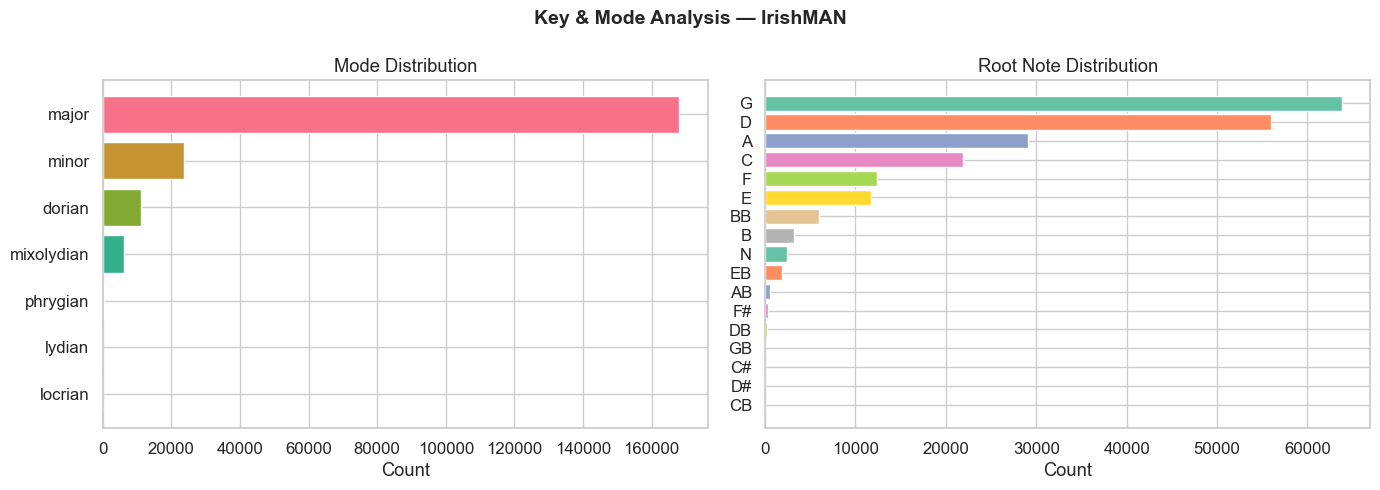

In [13]:
# ─── Visualize mode and key distributions ───
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Mode distribution
modes = [m for m, _ in mode_counts.most_common()]
mode_vals = [c for _, c in mode_counts.most_common()]
colors_mode = sns.color_palette('husl', len(modes))
axes[0].barh(modes, mode_vals, color=colors_mode)
axes[0].set_title('Mode Distribution')
axes[0].set_xlabel('Count')
axes[0].invert_yaxis()

# Root note distribution
roots = [r for r, _ in root_counts.most_common()]
root_vals = [c for _, c in root_counts.most_common()]
colors_root = sns.color_palette('Set2', len(roots))
axes[1].barh(roots, root_vals, color=colors_root)
axes[1].set_title('Root Note Distribution')
axes[1].set_xlabel('Count')
axes[1].invert_yaxis()

plt.suptitle('Key & Mode Analysis — IrishMAN', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(PROJECT_DIR / 'figures' / 'key_mode_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

## 1.7 Section Extraction (A-part / B-part)

Many folk tunes have AABB structure. Extract A- and B-sections for the Section Contrastive Loss.

In [14]:
def extract_sections(abc_body: str) -> list[str]:
    """
    Extract sections from ABC body by splitting on section delimiters.
    Returns list of section strings.
    """
    # Split on repeat/section markers
    # Common delimiters: |: (repeat start), :| (repeat end), :: (double repeat),
    # || (double barline), [| (thick-thin), |] (thin-thick)
    sections = re.split(r'\|:|:\||::|\|\||\[\||\|\]', abc_body)
    # Clean and filter empty sections
    sections = [s.strip() for s in sections if s.strip() and len(s.strip()) > 5]
    return sections

# Analyze section counts
section_count_dist = []
records_with_sections = 0

for rec in unique_records:
    sections = extract_sections(rec['abc_body'])
    rec['sections_list'] = sections
    rec['extracted_num_sections'] = len(sections)
    section_count_dist.append(len(sections))
    if len(sections) >= 2:
        records_with_sections += 1

print(f"Tunes with 2+ extracted sections: {records_with_sections:,} "
      f"({100*records_with_sections/len(unique_records):.1f}%)")
print(f"\nSection count distribution:")
for n, c in sorted(collections.Counter(section_count_dist).items()):
    print(f"  {n} sections: {c:,} tunes")

# Show example sections
for rec in unique_records[:5]:
    if len(rec['sections_list']) >= 2:
        print(f"\n--- Tune (key={rec['key']}, type={rec['tune_type']}) ---")
        for i, s in enumerate(rec['sections_list'][:3]):
            print(f"  Section {i}: {s[:80]}...")
        break

Tunes with 2+ extracted sections: 176,148 (84.1%)

Section count distribution:
  0 sections: 11 tunes
  1 sections: 33,203 tunes
  2 sections: 105,431 tunes
  3 sections: 30,000 tunes
  4 sections: 26,979 tunes
  5 sections: 5,658 tunes
  6 sections: 4,097 tunes
  7 sections: 1,578 tunes
  8 sections: 1,605 tunes
  9 sections: 345 tunes
  10 sections: 173 tunes
  11 sections: 105 tunes
  12 sections: 105 tunes
  13 sections: 33 tunes
  14 sections: 19 tunes
  15 sections: 4 tunes
  16 sections: 15 tunes
  19 sections: 1 tunes

--- Tune (key=Emin, type=reel) ---
  Section 0: E2 EF E2 EF | DEFG AFDF | E2 EF E2 B2 |1 efe^d e2 e2...
  Section 1: 2 efe^d e3 B...
  Section 2: e2 ef g2 fe | defg afdf |1 e2 ef g2 fe | efe^d e3 B...


## 1.8 Create Train / Validation / Test Splits

- **Train**: ~90% of unique tunes for pre-training
- **Validation**: ~5% for monitoring training loss
- **Test**: ~5% held out for final evaluation

We use the IrishMAN original val split as our test set, and split the train set into train+val.

In [15]:
from sklearn.model_selection import train_test_split

# Split unique_records into train + val (IrishMAN val becomes our test)
np.random.seed(42)

train_records, val_records_split = train_test_split(
    unique_records, test_size=0.05, random_state=42
)
test_records = unique_val  # IrishMAN's original val set

print(f"Train set: {len(train_records):,} tunes")
print(f"Val set:   {len(val_records_split):,} tunes")
print(f"Test set:  {len(test_records):,} tunes")

# Assign IDs
for i, rec in enumerate(train_records):
    rec['tune_id'] = f'train_{i:06d}'
for i, rec in enumerate(val_records_split):
    rec['tune_id'] = f'val_{i:06d}'
for i, rec in enumerate(test_records):
    rec['tune_id'] = f'test_{i:06d}'

Train set: 198,893 tunes
Val set:   10,469 tunes
Test set:  2,162 tunes


## 1.9 Save Processed Data

In [16]:
import pyarrow as pa
import pyarrow.parquet as pq

def save_records(records, name, output_dir):
    """Save records as both JSON and Parquet."""
    # Remove sections_list for serialization (it's a list of strings)
    serializable = []
    for r in records:
        r_copy = {k: v for k, v in r.items() if k != 'sections_list'}
        serializable.append(r_copy)
    
    # Save JSON
    json_path = output_dir / f'{name}.json'
    with open(json_path, 'w') as f:
        json.dump(serializable, f)
    
    # Save Parquet
    df = pd.DataFrame(serializable)
    parquet_path = output_dir / f'{name}.parquet'
    df.to_parquet(parquet_path, index=False)
    
    print(f"Saved {name}: {len(records):,} records")
    print(f"  JSON:    {json_path} ({json_path.stat().st_size / 1e6:.1f} MB)")
    print(f"  Parquet: {parquet_path} ({parquet_path.stat().st_size / 1e6:.1f} MB)")
    return df

# Save all splits
train_df = save_records(train_records, 'train', PROCESSED_DIR)
val_df = save_records(val_records_split, 'val', PROCESSED_DIR)
test_df = save_records(test_records, 'test', PROCESSED_DIR)

# Also save a combined metadata CSV for quick reference
all_df = pd.concat([train_df, val_df, test_df], ignore_index=True)
meta_cols = ['tune_id', 'key', 'meter', 'tune_type', 'root_note', 'mode', 
             'num_bars', 'num_sections', 'char_length', 'source']
meta_df = all_df[[c for c in meta_cols if c in all_df.columns]]
meta_path = PROCESSED_DIR / 'metadata.csv'
meta_df.to_csv(meta_path, index=False)
print(f"\nMetadata CSV saved: {meta_path}")
print(f"Total tunes in processed corpus: {len(all_df):,}")

Saved train: 198,893 records
  JSON:    /Volumes/LLModels/ABC2VEC/data/processed/train.json (194.3 MB)
  Parquet: /Volumes/LLModels/ABC2VEC/data/processed/train.parquet (73.4 MB)
Saved val: 10,469 records
  JSON:    /Volumes/LLModels/ABC2VEC/data/processed/val.json (10.2 MB)
  Parquet: /Volumes/LLModels/ABC2VEC/data/processed/val.parquet (3.9 MB)
Saved test: 2,162 records
  JSON:    /Volumes/LLModels/ABC2VEC/data/processed/test.json (2.0 MB)
  Parquet: /Volumes/LLModels/ABC2VEC/data/processed/test.parquet (0.8 MB)

Metadata CSV saved: /Volumes/LLModels/ABC2VEC/data/processed/metadata.csv
Total tunes in processed corpus: 211,524


In [17]:
# ─── Save section pairs for Section Contrastive Loss ───
# Extract (section_A, section_B, tune_id) pairs from tunes with 2+ sections
section_pairs = []

for rec in train_records:
    if 'sections_list' in rec and len(rec['sections_list']) >= 2:
        sections = rec['sections_list']
        # Create pairs from consecutive sections (A-B, B-C, etc.)
        for j in range(len(sections) - 1):
            section_pairs.append({
                'tune_id': rec['tune_id'],
                'section_a': sections[j],
                'section_b': sections[j + 1],
                'key': rec['key'],
                'tune_type': rec['tune_type']
            })

print(f"Section pairs extracted: {len(section_pairs):,}")

# Save section pairs
section_pairs_path = PROCESSED_DIR / 'section_pairs.json'
with open(section_pairs_path, 'w') as f:
    json.dump(section_pairs, f)
print(f"Section pairs saved to {section_pairs_path}")

# Show examples
for sp in section_pairs[:3]:
    print(f"\nTune {sp['tune_id']} ({sp['tune_type']}, {sp['key']}):")
    print(f"  A: {sp['section_a'][:60]}...")
    print(f"  B: {sp['section_b'][:60]}...")

Section pairs extracted: 302,005
Section pairs saved to /Volumes/LLModels/ABC2VEC/data/processed/section_pairs.json

Tune train_000000 (reel, D):
  A: A3 B ADFA | BAFA EGFE | DA, A,2 DFAF | GBAG FD D2 | A3 B ADF...
  B: d3 f af f2 | afbf afef | d2 fd Adfa | bfaf e3 z | fa a2 afdf...

Tune train_000001 (polka, Amin):
  A: c/d/ | eA BA/^G/ | c>d e/f/g | eA BA/^G/ | AB/c/ dc/d/ | eA ...
  B: e/f/ | g>e c/d/e/f/ | g>e d(3e/f/g/ | ae dc/d/ | ed dc/d/ | ...

Tune train_000003 (waltz, D):
  A: DE |"D" F4 F2 |"D/C#" F4 FE |"D/B" FA- A3 B |"D/A" AF D2 DE ...
  B: (3ABc |"D" d3 c de |"D/C#" dc BA Bc |"D/B" d3 B AF |"D/A" D4...


## 1.10 Data Pipeline Summary

Final summary of all processed datasets.

In [18]:
print("=" * 60)
print("ABC2Vec Data Pipeline — Summary")
print("=" * 60)
print(f"\nPrimary Corpus (IrishMAN, pre-training):")
print(f"  Train: {len(train_records):,} tunes")
print(f"  Val:   {len(val_records_split):,} tunes")
print(f"  Test:  {len(test_records):,} tunes")
print(f"  Section pairs: {len(section_pairs):,}")
print(f"\nMetadata breakdown:")
print(f"  Tune types: {len(set(r['tune_type'] for r in unique_records if r['tune_type']))}")
print(f"  Keys:       {len(set(r['key'] for r in unique_records))}")
print(f"  Modes:      {list(mode_counts.keys())}")
print(f"\nAll data saved to: {PROCESSED_DIR}")
print(f"Files:")
for f in sorted(PROCESSED_DIR.glob('*')):
    print(f"  {f.name} ({f.stat().st_size / 1e6:.1f} MB)")

ABC2Vec Data Pipeline — Summary

Primary Corpus (IrishMAN, pre-training):
  Train: 198,893 tunes
  Val:   10,469 tunes
  Test:  2,162 tunes
  Section pairs: 302,005

Metadata breakdown:
  Tune types: 6
  Keys:       62
  Modes:      ['minor', 'major', 'dorian', 'phrygian', 'mixolydian', 'lydian', 'locrian']

All data saved to: /Volumes/LLModels/ABC2VEC/data/processed
Files:
  metadata.csv (10.7 MB)
  model_config.json (0.0 MB)
  section_pairs.json (85.2 MB)
  test.json (2.0 MB)
  test.parquet (0.8 MB)
  tokenizer_config.json (0.0 MB)
  train.json (194.3 MB)
  train.parquet (73.4 MB)
  val.json (10.2 MB)
  val.parquet (3.9 MB)
  vocab.json (0.0 MB)
